# Image Thresholding

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [49]:
%matplotlib inline

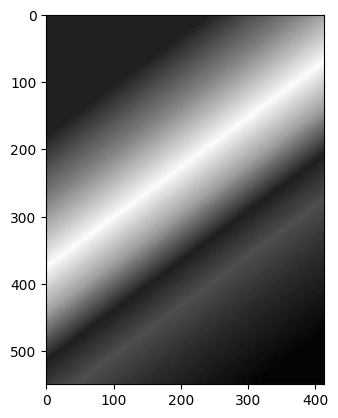

In [45]:
# type: ignore
image: cv2.typing.MatLike  = cv2.imread('../../.data/rainbow.jpg', 0)
plt.imshow(image, cmap='gray') 

In [50]:
image.max()

np.uint8(214)

In [61]:
_, thresh_01 = cv2.threshold(image, 127.5, 255.0, cv2.THRESH_TOZERO)

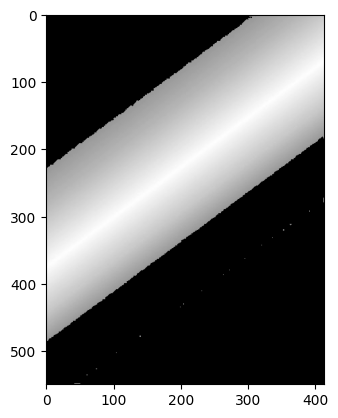

In [62]:
plt.imshow(thresh_01, cmap='gray')

In [87]:
def show_pic(img):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

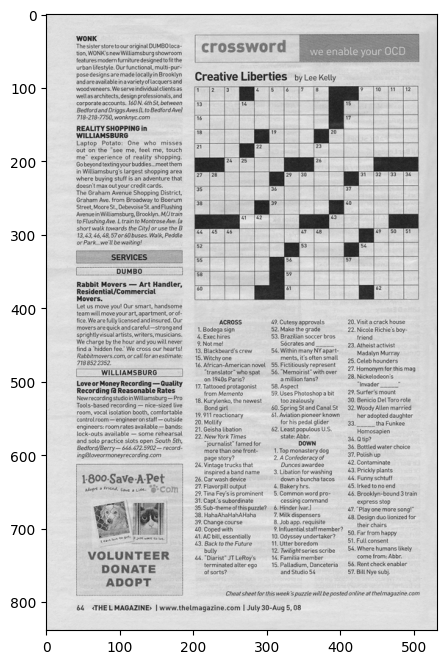

In [88]:
# type: ignore
image: cv2.typing.MatLike  = cv2.imread('../../.data/crossword.jpg', 0)
show_pic(image)

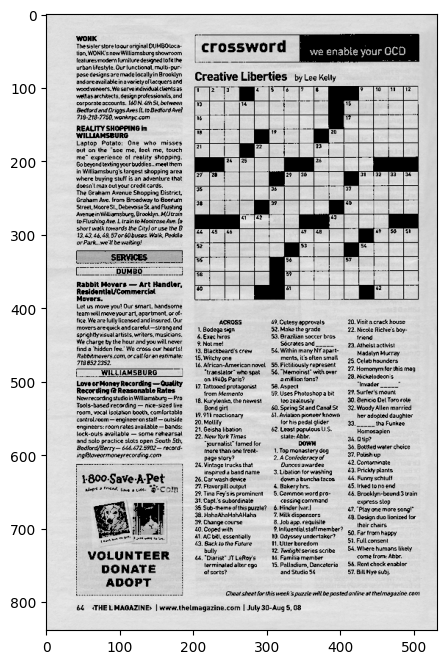

In [89]:
_, thresh_02 = cv2.threshold(image, 150.5, 255.0, cv2.THRESH_TOZERO)
show_pic(thresh_02)

## Umbral Adaptativo (Adaptive Thresholding)

En los ejemplos anteriores utilizamos un valor de umbral global. Sin embargo, esto no siempre es ideal si la imagen tiene diferentes condiciones de iluminación en diferentes áreas. En esos casos, el **Umbral Adaptativo** es más eficaz, ya que calcula el umbral para pequeñas regiones de la imagen.

### Parámetros de `cv2.adaptiveThreshold`:

| Parámetro | Tipo | Descripción |
|-----------|------|-------------|
| **src** | `cv2.typing.MatLike` | Imagen de origen de 8 bits y un solo canal (escala de grises). |
| **maxValue** | `float` | Valor no nulo asignado a los píxeles que cumplen la condición. |
| **adaptiveMethod** | `int` | Algoritmo de umbralización adaptativa a utilizar:<br>- `cv2.ADAPTIVE_THRESH_MEAN_C`: Promedio del área de vecindad<br>- `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: Suma ponderada (Gaussiana) |
| **thresholdType** | `int` | Tipo de umbralización (`cv2.THRESH_BINARY` o `cv2.THRESH_BINARY_INV`). |
| **blockSize** | `int` | Tamaño de la vecindad de píxeles (debe ser un número impar: 3, 5, 7, etc.). |
| **C** | `float` | Constante que se resta de la media o media ponderada. Puede ser positiva, cero o negativa. |

[Referencia en StackOverflow](https://stackoverflow.com/questions/28763419/adaptive-threshold-parameters-confusion)

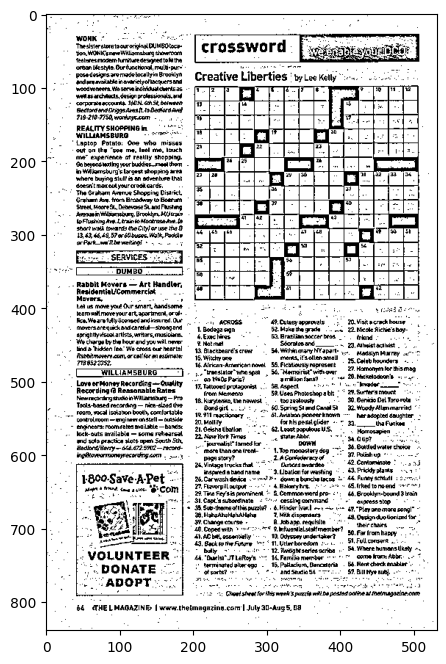

In [90]:
thresh_03: cv2.typing.MatLike = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)
show_pic(thresh_03)

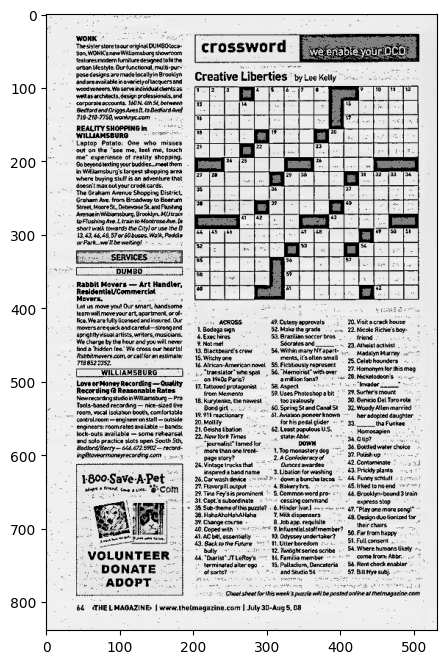

In [92]:
result = cv2.addWeighted(src1=thresh_02, alpha=0.5, src2=thresh_03, beta=0.5, gamma=0)
show_pic(result)